In [1]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="gpt-oss:120b-cloud")
print('Model is ready')


c:\Users\ak60492\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Model is ready


In [2]:
from langchain_community.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get weather for a city"""
    return f"The weather in the city {city} is Sunny"

@tool
def get_stock_price(stock: str) -> str:
    """Returns the stock price for a given stock"""
    return f"The stock price of {stock} is 25.50"

@tool
def transfer_funds(fromAccount: str, toAccount: str, amount: float) -> str:
    """Transfers money from fromAccount to toAccount as per given amount value"""
    return f"Transferred {amount} from {fromAccount} to {toAccount}"

ALL_TOOLS = [get_weather, get_stock_price, transfer_funds]
SENSITIVE_TOOLS = {"transfer_funds"}
print(f'All Tools: {ALL_TOOLS}')

print('Tools are ready')

All Tools: [StructuredTool(name='get_weather', description='Get weather for a city', args_schema=<class 'langchain_core.utils.pydantic.get_weather'>, func=<function get_weather at 0x00000155D889E8E0>), StructuredTool(name='get_stock_price', description='Returns the stock price for a given stock', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x00000155F7D94F40>), StructuredTool(name='transfer_funds', description='Transfers money from fromAccount to toAccount as per given amount value', args_schema=<class 'langchain_core.utils.pydantic.transfer_funds'>, func=<function transfer_funds at 0x00000155F7E25F80>)]
Tools are ready


In [3]:
# STEP 1 - Define the central state of the application
from typing import Annotated, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

print('Graph State is ready')


Graph State is ready


In [19]:
# STEP 2 - Define your nodes
from langchain_core.messages import SystemMessage, ToolMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import Command, interrupt

llm_with_tools = model.bind_tools(ALL_TOOLS)

HITL_SYSTEM_PROMPT = SystemMessage(content=(
    "You have access to get_weather, get_stock_price, and transfer_funds. "
    "When the user asks to transfer funds do not call the tool and please ask the user to confirm "
    "If human reviewer approves then call the tool and if user denies then don't call the tool"
))
HITL_SYSTEM_PROMPT = SystemMessage(content=(
    "You have access to get_weather, get_stock_price, and transfer_funds. "
    "When the user asks to transfer funds, immediately call the transfer_funds "
    "tool with the requested amount and account - do not ask the user to confirm "
    "in plain text first. A human reviewer approves or denies the transfer "
    "automatically before it executes, so your job is only to call the tool."
))

def assistant_hitl(state:AgentState) -> dict:
    """Assistant node: call the model, allowing it to request tools."""
    response = llm_with_tools.invoke([HITL_SYSTEM_PROMPT] + state['messages'])
    return {"messages": [response]}

def route_after_assistant_hitl(state:AgentState) -> str:
    """Route to tools only when model produces tool calls"""
    last_message = state['messages'][-1]
    tool_calls = getattr(last_message, "tool_calls", None)
    if not tool_calls:
        return END
    if any(tool_call["name"] in SENSITIVE_TOOLS for tool_call in tool_calls):
        return "human_review"
    return "tools"

def human_review_hitl(state:AgentState) -> Command:
    """Pauses the graph and ask a human to approve the pending sensitive tool call."""
    last_message = state['messages'][-1]
    tool_call = last_message.tool_calls[0] # transfer_funds tool

    decision = interrupt({
        "question": "Shall I transfer the funds?",
        "tool": tool_call["name"],
        "args": tool_call["args"]
    })
    if decision == "approve":
        return Command(goto="tools")

    denial = ToolMessage(
        content="User rejected the transfer funds action",
        tool_call_id=tool_call["id"]
    )
    return Command(goto="assistant_hitl", update={"messages": [denial]})

print('Nodes are ready')

Nodes are ready


In [25]:
# STEP 3 - Bind nodes together using Edges
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

tools_graph_builder = StateGraph(AgentState)

# Node registration
tools_graph_builder.add_node("assistant_hitl", assistant_hitl) # invokes the LLM
tools_graph_builder.add_node("tools", ToolNode(ALL_TOOLS)) # invokes the suggested tool
tools_graph_builder.add_node("human_review_hitl", human_review_hitl) # takes human's approval

# Add edges to nodes
tools_graph_builder.add_edge(START, "assistant_hitl")
tools_graph_builder.add_conditional_edges(
    "assistant_hitl",
    route_after_assistant_hitl,
    {
        "tools": "tools",
        "human_review": "human_review_hitl",
        END: END
    }
)
tools_graph_builder.add_edge("tools", "assistant_hitl")

memory = MemorySaver()
tool_graph = tools_graph_builder.compile(checkpointer=memory)
print('Tool graph is ready')

Tool graph is ready


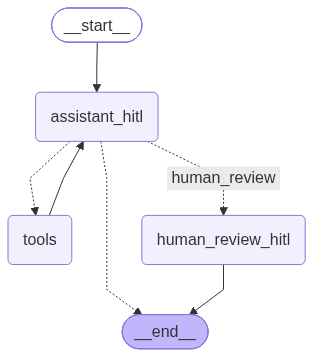

In [26]:
tool_graph

In [16]:
pending = tool_graph.invoke({
    "messages": [
        {"role": "user", "content": "Which is the capital city of India?"}
    ]
})

if "__interrupt__" in pending:
    print('Graph is paused.. the interrupt payload is ')
    print(pending["__interrupt__"])
else:
    print("No interrupt called.. graph executed successfully..")
    print(pending)


No interrupt called.. graph executed successfully..
{'messages': [HumanMessage(content='Which is the capital city of India?', additional_kwargs={}, response_metadata={}, id='caeea63d-4559-469a-a64a-450c7632d4ad'), AIMessage(content='The capital city of India is **New\u202fDelhi**.', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-18T05:15:14.085095469Z', 'done': True, 'done_reason': 'stop', 'total_duration': 326574832, 'load_duration': None, 'prompt_eval_count': 253, 'prompt_eval_duration': None, 'eval_count': 48, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0b2f0-ae17-7b22-aba0-afcc4fbcd9e5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 253, 'output_tokens': 48, 'total_tokens': 301})]}


In [12]:
pending = tool_graph.invoke({
    "messages": [
        {"role": "user", "content": "How is the weather in Pune city today?"}
    ]
})

if "__interrupt__" in pending:
    print('Graph is paused.. the interrupt payload is ')
    print(pending["__interrupt__"])
else:
    print("No interrupt called.. graph executed successfully..")
    print(pending)


No interrupt called.. graph executed successfully..
{'messages': [HumanMessage(content='How is the weather in Pune city today?', additional_kwargs={}, response_metadata={}, id='01c23b1d-637f-4aac-9acb-89780c1d34f1'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-18T05:09:45.364351243Z', 'done': True, 'done_reason': 'stop', 'total_duration': 378452795, 'load_duration': None, 'prompt_eval_count': 249, 'prompt_eval_duration': None, 'eval_count': 41, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0b2eb-aa22-7a72-963e-528c3f2c837c-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Pune'}, 'id': '65b6cd1d-5611-4fb9-b150-a8b9450b80db', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 249, 'output_tokens': 41, 'total_tokens': 290}), ToolMessage(content='The weather in the city Pune is Sunny', name='get_weather', id='4c8719c9-ec

In [31]:
hitl_config = {"configurable": {"thread_id": "bank_session"}}
pending = tool_graph.invoke({
    "messages": [
        {"role": "user", "content": "Please transfer 2000 USD from account number ACC-100 to account number ACC-200"}
    ]
},
hitl_config
)

if "__interrupt__" in pending:
    print('Graph is paused.. the interrupt payload is ')
    print(pending["__interrupt__"])
else:
    print("No interrupt called.. graph executed successfully..")
    print(pending)


Graph is paused.. the interrupt payload is 
[Interrupt(value={'question': 'Shall I transfer the funds?', 'tool': 'transfer_funds', 'args': {'amount': 2000, 'fromAccount': 'ACC-100', 'toAccount': 'ACC-200'}}, id='fcbabf0625c2e72493926d1194164ea2')]


In [ ]:
command = Command(resume="approve")
approved_response = tool_graph.invoke(command, hitl_config)

print('Final answer')
print(approved_response['messages'][-1].content)
print(approved_response)

Final answer
{'messages': [HumanMessage(content='Please transfer 2000 USD from account number ACC-100 to account number ACC-200', additional_kwargs={}, response_metadata={}, id='10b0cad5-cb3d-4579-86ba-9c2584f7b73e'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-18T05:25:43.039593182Z', 'done': True, 'done_reason': 'stop', 'total_duration': 415135381, 'load_duration': None, 'prompt_eval_count': 284, 'prompt_eval_duration': None, 'eval_count': 89, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0b2fa-4678-76f1-9057-787b446e5576-0', tool_calls=[{'name': 'transfer_funds', 'args': {'amount': 2000, 'fromAccount': 'ACC-100', 'toAccount': 'ACC-200'}, 'id': 'f4b2506a-419e-49d3-9f45-b2201775b7c5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 284, 'output_tokens': 89, 'total_tokens': 373}), ToolMessage(content='Transferred 2000.0 fr

In [32]:
command = Command(resume="deny")
approved_response = tool_graph.invoke(command, hitl_config)

print('Final answer')
print(approved_response['messages'][-1].content)
print(approved_response)

Final answer
I wasn’t able to complete the transfer—your request was declined. If you’d like to try a different amount or need help with something else, just let me know!
{'messages': [HumanMessage(content='Please transfer 2000 USD from account number ACC-100 to account number ACC-200', additional_kwargs={}, response_metadata={}, id='10b0cad5-cb3d-4579-86ba-9c2584f7b73e'), AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-18T05:25:43.039593182Z', 'done': True, 'done_reason': 'stop', 'total_duration': 415135381, 'load_duration': None, 'prompt_eval_count': 284, 'prompt_eval_duration': None, 'eval_count': 89, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0b2fa-4678-76f1-9057-787b446e5576-0', tool_calls=[{'name': 'transfer_funds', 'args': {'amount': 2000, 'fromAccount': 'ACC-100', 'toAccount': 'ACC-200'}, 'id': 'f4b2506a-419e-49d3-9f45-b2201775b7c5', 'type': 'to